# 01. Análise descritiva (EDA)

Exploração visual de `registro_limpo` (saída do NB00b) — missing, nomes, sexo, data de nascimento, idade, CEP, UF.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROB_DIR = Path.cwd()
if PROB_DIR.name == 'notebooks':
    PROB_DIR = PROB_DIR.parent
if str(PROB_DIR) not in sys.path:
    sys.path.insert(0, str(PROB_DIR))

%matplotlib inline

import config
from config import (
    ANO_REFERENCIA_CENSO, TABELA_LIMPA, USE_PHONETIC_STRIP_VOWELS,
    get_connection, print_paths, require_tables,
)

# Descreve o que o Splink vai ver, ou seja, a base já limpa (NB00b). O antes e
# depois da limpeza em si fica no próprio NB00b.
TABLE = TABELA_LIMPA
ORIGEM_COLORS = {'cpf': '#2563eb', 'censo': '#16a34a'}


def _is_filled(col: str) -> str:
    return f"({col} IS NOT NULL AND TRIM(CAST({col} AS VARCHAR)) <> '')"


def plot_origem_counts(df, *, title='Registros por origem'):
    fig, ax = plt.subplots(figsize=(6, 4))
    colors = [ORIGEM_COLORS.get(o, '#64748b') for o in df['origem']]
    ax.bar(df['origem'], df['n'], color=colors)
    ax.set_title(title)
    ax.set_ylabel('Quantidade')
    for i, v in enumerate(df['n']):
        ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_missingness_bars(df, *, title='Preenchimento por coluna (%)'):
    if df.empty:
        return
    pivot = df.pivot(index='coluna', columns='origem', values='pct_preenchido').fillna(0)
    fig, ax = plt.subplots(figsize=(10, max(4, len(pivot) * 0.35)))
    pivot.plot(kind='barh', ax=ax, color=[ORIGEM_COLORS.get(c, '#64748b') for c in pivot.columns])
    ax.set_xlabel('% preenchido')
    ax.set_title(title)
    ax.legend(title='Origem')
    ax.set_xlim(0, 100)
    plt.tight_layout()
    plt.show()


def plot_top_bars(df, *, title, value_col='valor', split_by_origem=True):
    if df.empty:
        return
    origens = df['origem'].unique() if split_by_origem else [None]
    ncols = len(origens) if split_by_origem else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6), squeeze=False)
    for idx, orig in enumerate(origens if split_by_origem else [None]):
        ax = axes[0, idx]
        sub = df[df['origem'] == orig].head(20) if orig else df.head(20)
        sub = sub.sort_values('n')
        color = ORIGEM_COLORS.get(orig, '#64748b') if orig else '#64748b'
        ax.barh(sub[value_col], sub['n'], color=color)
        ax.set_title(f'{title}' + (f' — {orig}' if orig else ''))
        ax.set_xlabel('Quantidade')
    plt.tight_layout()
    plt.show()


def plot_sexo_distribution(df):
    if df.empty:
        return
    pivot = df.pivot(index='sexo_cat', columns='origem', values='n').fillna(0)
    fig, ax = plt.subplots(figsize=(7, 4))
    pivot.plot(kind='bar', ax=ax, color=[ORIGEM_COLORS.get(c, '#64748b') for c in pivot.columns])
    ax.set_title('Distribuição de sexo')
    ax.set_ylabel('Quantidade')
    ax.set_xlabel('Sexo')
    ax.legend(title='Origem')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_dob_year_hist(df):
    if df.empty:
        return
    fig, ax = plt.subplots(figsize=(10, 4))
    for orig in df['origem'].unique():
        sub = df[df['origem'] == orig]
        ax.hist(
            sub['ano'], bins=30, alpha=0.55, label=orig,
            weights=sub['n'], color=ORIGEM_COLORS.get(orig, '#64748b'),
        )
    ax.set_title('Distribuição do ano de nascimento')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Quantidade')
    ax.legend(title='Origem')
    plt.tight_layout()
    plt.show()


def plot_idade_hist(df, *, ano_ref=ANO_REFERENCIA_CENSO):
    if df.empty:
        return
    fig, ax = plt.subplots(figsize=(10, 4))
    for orig in df['origem'].unique():
        sub = df[df['origem'] == orig]
        ax.hist(
            sub['idade'], bins=range(0, 101, 5), alpha=0.55, label=orig,
            weights=sub['n'], color=ORIGEM_COLORS.get(orig, '#64748b'),
        )
    ax.set_title(f'Distribuição de idade (referência Censo {ano_ref})')
    ax.set_xlabel('Idade (anos)')
    ax.set_ylabel('Quantidade')
    ax.legend(title='Origem')
    plt.tight_layout()
    plt.show()


def plot_cep_prefix(df, *, title='Top prefixos CEP (5 dígitos)'):
    plot_top_bars(df, title=title, value_col='cep5')


def plot_uf_distribution(df):
    if df.empty:
        return
    fig, ax = plt.subplots(figsize=(8, 4))
    for orig in df['origem'].unique():
        sub = df[df['origem'] == orig].sort_values('n', ascending=False).head(10)
        ax.bar(
            [f'{orig}:{u}' for u in sub['uf']], sub['n'],
            color=ORIGEM_COLORS.get(orig, '#64748b'), alpha=0.85, label=orig,
        )
    ax.set_title('UF — top 10 por origem')
    ax.set_ylabel('Quantidade')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


print_paths()
print('FILTRO_UF:', config.FILTRO_UF, '| FILTRO_MUNICIPIO:', config.FILTRO_MUNICIPIO)
con = get_connection()
require_tables(con, [TABLE], notebook_origem='00b')

OUTPUT_DIR: /home/ibge.gov.br/ramon.goncalves/data/probabilistico_output
CPF_ARQUIVO: /home/ibge.gov.br/ramon.goncalves/singed/bases/bronze/cpf/cpf.parquet
CENSO_PESSOAS_ARQUIVO: /home/ibge.gov.br/ramon.goncalves/singed/bases/bronze/censo/censo_pessoas_2022_20260505.parquet
CENSO_CEP_ARQUIVO: /home/ibge.gov.br/ramon.goncalves/singed/bases/raw/censo/data_cep_uniq.csv
COHORT_DEDUP_ARQUIVO: /home/ibge.gov.br/ramon.goncalves/capefe/dados/CohortDados/cohort_dedup.parquet
FILTRO_UF: None
FILTRO_MUNICIPIO: 2111300
USE_PHONETIC_STRIP_VOWELS: False
ANO_OBITO_CORTE: 2021
ANO_NASCIMENTO_MIN: 1900
SEXO_VALIDOS: ('M', 'F')
DUCKDB_ARQUIVO: /home/ibge.gov.br/ramon.goncalves/data/probabilistico_output/probabilistico.duckdb
FILTRO_UF: None | FILTRO_MUNICIPIO: 2111300


## 1. Visão geral


,origem,n
0,censo,1037775
1,cpf,1438943


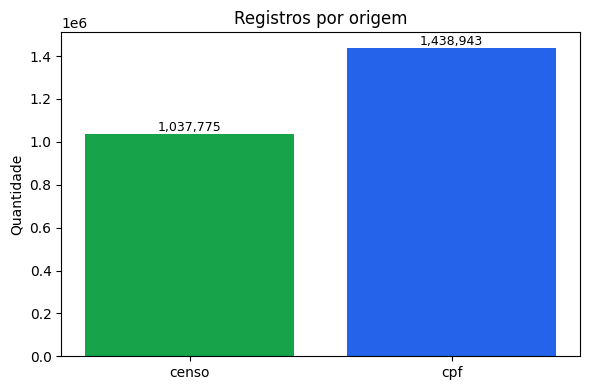

In [2]:
df_origem = con.execute(f"""
SELECT origem, COUNT(*) AS n
FROM {TABLE}
GROUP BY origem
ORDER BY origem
""").df()
display(df_origem)
plot_origem_counts(df_origem)

### Município (`cod_municipio`)

Coerência com `FILTRO_MUNICIPIO` (IBGE 7 dígitos).

In [3]:
cols = set(con.execute(f'SELECT * FROM {TABLE} LIMIT 0').df().columns)
if 'cod_municipio' in cols:
    display(con.execute(f'''
    SELECT origem, cod_municipio, COUNT(*) AS n
    FROM {TABLE}
    WHERE cod_municipio IS NOT NULL AND TRIM(CAST(cod_municipio AS VARCHAR)) <> ''
    GROUP BY origem, cod_municipio
    ORDER BY n DESC
    LIMIT 10
    ''').df())
else:
    print('cod_municipio ausente — rode NB00 com REBUILD=True')

,origem,cod_municipio,n
0,cpf,2111300,1438943
1,censo,2111300,1037775


## 2. Missingness


origem,censo,cpf
coluna,,
cep,0.0,0.0
cpf_norm,100.0,0.0
data_nascimento,16.7,2.3
idade,0.0,2.3
nome_completo,4.4,0.0
nome_completo_phon,4.4,0.0
nome_mae,71.1,4.2
nome_mae_phon,71.1,4.2
nome_meio,21.8,3.4


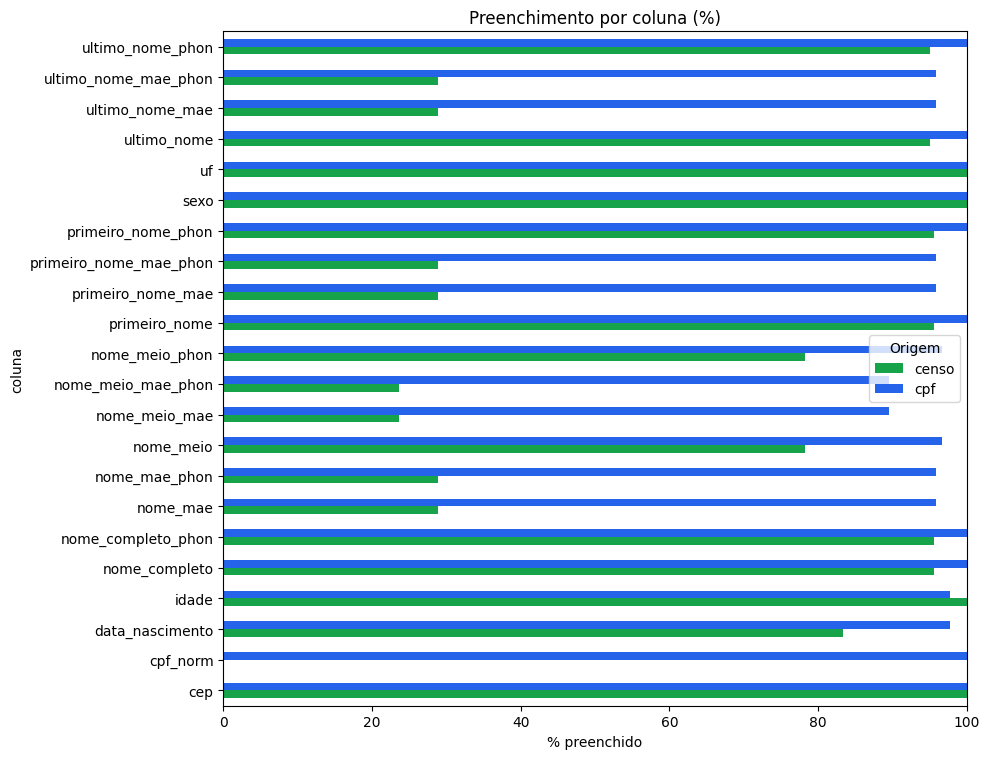

In [4]:
EDA_COLS = [
    'nome_completo', 'primeiro_nome', 'nome_meio', 'ultimo_nome',
    'nome_mae', 'primeiro_nome_mae', 'nome_meio_mae', 'ultimo_nome_mae',
    'sexo', 'data_nascimento', 'idade', 'cep', 'uf', 'cpf_norm',
    'nome_completo_phon', 'primeiro_nome_phon', 'nome_meio_phon', 'ultimo_nome_phon',
    'nome_mae_phon', 'primeiro_nome_mae_phon', 'nome_meio_mae_phon', 'ultimo_nome_mae_phon',
]
if USE_PHONETIC_STRIP_VOWELS:
    EDA_COLS += [
        'nome_completo_phon_sv', 'primeiro_nome_phon_sv', 'nome_meio_phon_sv', 'ultimo_nome_phon_sv',
        'nome_mae_phon_sv', 'primeiro_nome_mae_phon_sv', 'nome_meio_mae_phon_sv', 'ultimo_nome_mae_phon_sv',
    ]

available = set(con.execute(f'SELECT * FROM {TABLE} LIMIT 0').df().columns)
cols = [c for c in EDA_COLS if c in available]

rows = []
for col in cols:
    rows.append(con.execute(f"""
    SELECT
        '{col}' AS coluna,
        origem,
        COUNT(*) AS n,
        SUM(CASE WHEN {_is_filled(col)} THEN 1 ELSE 0 END) AS preenchido
    FROM {TABLE}
    GROUP BY origem
    """).df())

df_missing = pd.concat(rows, ignore_index=True)
df_missing['pct_preenchido'] = (df_missing['preenchido'] / df_missing['n'] * 100).round(1)
df_missing['pct_missing'] = (100 - df_missing['pct_preenchido']).round(1)

display(df_missing.pivot(index='coluna', columns='origem', values='pct_missing').round(1))
plot_missingness_bars(df_missing)

## 3. Nomes


,origem,valor,n
0,cpf,MARIA,111164
1,censo,MARIA,71778
2,cpf,JOSE,54154
3,cpf,ANA,30263
4,censo,JOSE,28895
5,cpf,JOAO,28179
6,censo,ANA,23934
7,cpf,ANTONIO,20756
8,censo,JOAO,17764
9,cpf,RAIMUNDO,17541


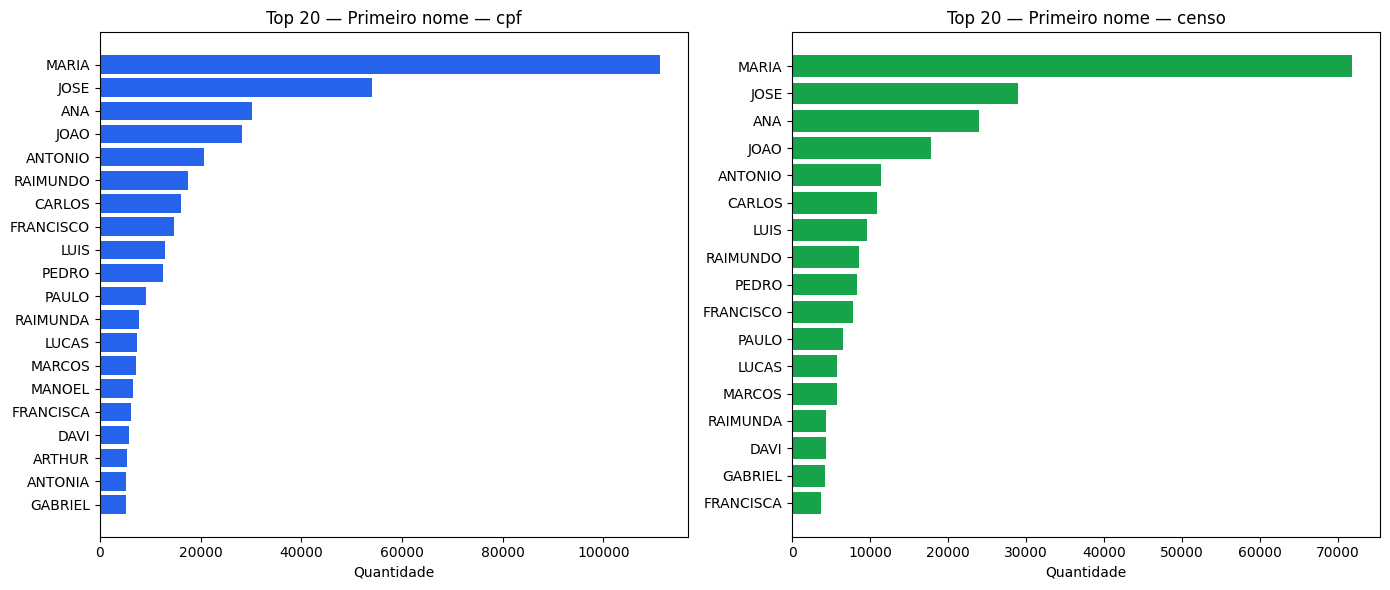

,origem,valor,n
0,cpf,SILVA,150318
1,cpf,SANTOS,103177
2,censo,SILVA,95414
3,censo,SANTOS,67232
4,cpf,COSTA,51995
5,cpf,SOUSA,48424
6,cpf,PEREIRA,43208
7,censo,SOUSA,35571
8,censo,COSTA,34852
9,cpf,OLIVEIRA,34166


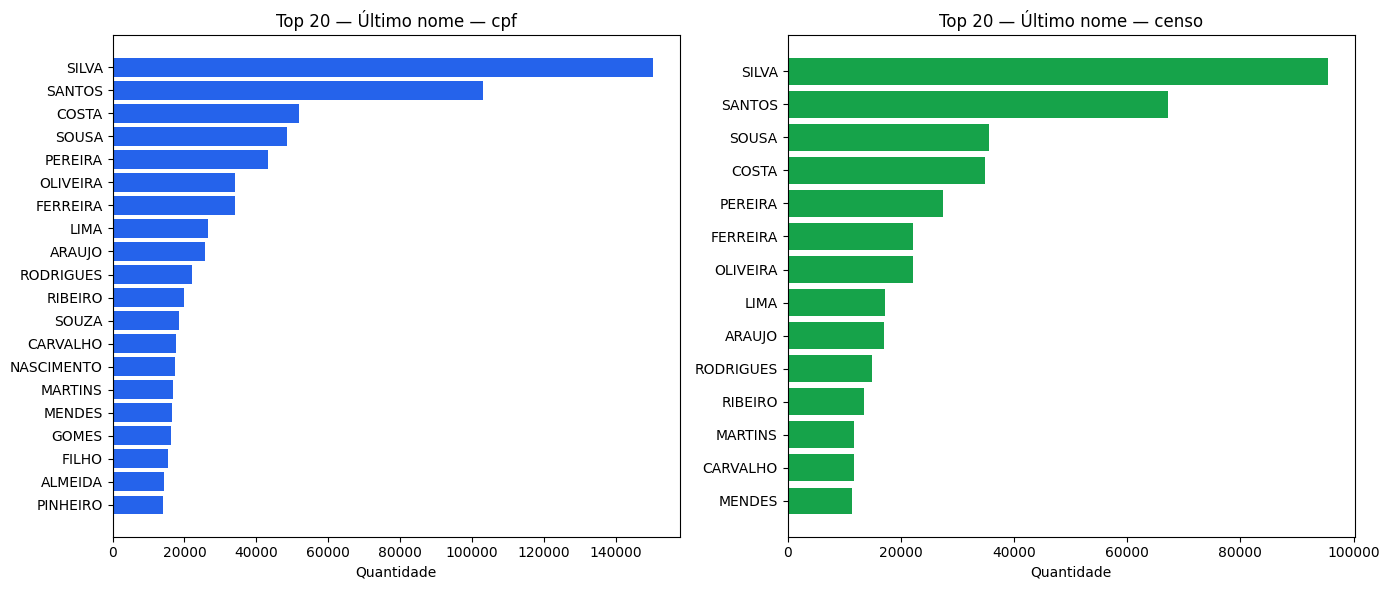

,origem,n,com_meio,pct_meio
0,censo,1037775,811508.0,78.2
1,cpf,1438943,1389442.0,96.6


In [5]:
for col, titulo in [('primeiro_nome', 'Primeiro nome'), ('ultimo_nome', 'Último nome')]:
    df_top = con.execute(f"""
    SELECT origem, CAST({col} AS VARCHAR) AS valor, COUNT(*) AS n
    FROM {TABLE}
    WHERE {_is_filled(col)}
    GROUP BY origem, valor
    ORDER BY n DESC
    LIMIT 40
    """).df()
    display(df_top.head(10))
    plot_top_bars(df_top, title=f'Top 20 — {titulo}')

display(con.execute(f"""
SELECT
    origem,
    COUNT(*) AS n,
    SUM(CASE WHEN {_is_filled('nome_meio')} THEN 1 ELSE 0 END) AS com_meio,
    ROUND(100.0 * SUM(CASE WHEN {_is_filled('nome_meio')} THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_meio
FROM {TABLE}
GROUP BY origem
""").df())

## 4. Sexo


,origem,sexo_cat,n
0,censo,F,554274
1,censo,M,483501
2,cpf,(vazio),214
3,cpf,F,732727
4,cpf,M,706002


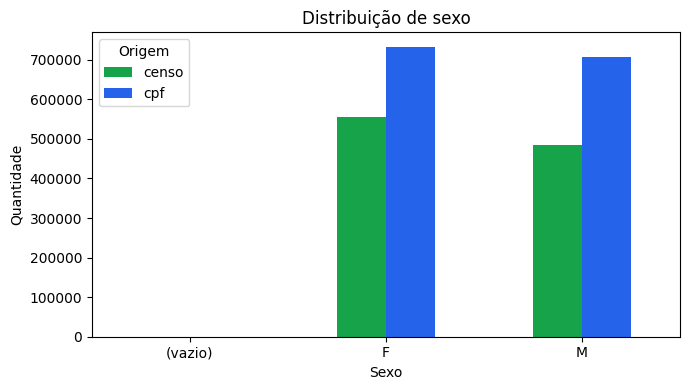

In [6]:
df_sexo = con.execute(f"""
SELECT
    origem,
    CASE
        WHEN NOT ({_is_filled('sexo')}) THEN '(vazio)'
        WHEN UPPER(TRIM(CAST(sexo AS VARCHAR))) IN ('M', 'MASC', 'MASCULINO', '1') THEN 'M'
        WHEN UPPER(TRIM(CAST(sexo AS VARCHAR))) IN ('F', 'FEM', 'FEMININO', '2') THEN 'F'
        ELSE 'outro'
    END AS sexo_cat,
    COUNT(*) AS n
FROM {TABLE}
GROUP BY origem, sexo_cat
ORDER BY origem, sexo_cat
""").df()
display(df_sexo)
plot_sexo_distribution(df_sexo)

## 5. Data de nascimento


,origem,com_ano_valido
0,censo,864840
1,cpf,1405661


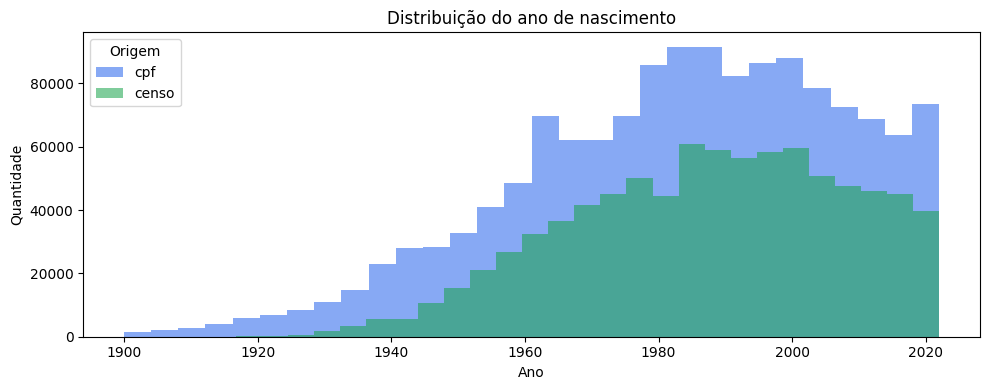

In [7]:
df_dob = con.execute(f"""
SELECT
    origem,
    TRY_CAST(substr(CAST(data_nascimento AS VARCHAR), 1, 4) AS INTEGER) AS ano,
    COUNT(*) AS n
FROM {TABLE}
WHERE {_is_filled('data_nascimento')}
  AND TRY_CAST(substr(CAST(data_nascimento AS VARCHAR), 1, 4) AS INTEGER) BETWEEN 1900 AND 2025
GROUP BY origem, ano
ORDER BY ano
""").df()
display(df_dob.groupby('origem')['n'].sum().reset_index(name='com_ano_valido'))
plot_dob_year_hist(df_dob)

## 5b. Idade (referência Censo 2022)

Censo: `PECP0003` (anos), fallback `PECP0030` (meses). CPF: `2022 - ano(data_nascimento)`.

,origem,n,com_idade,pct_idade,idade_media
0,cpf,1438943,1405661.0,97.7,39.0
1,censo,1037775,1037775.0,100.0,34.3


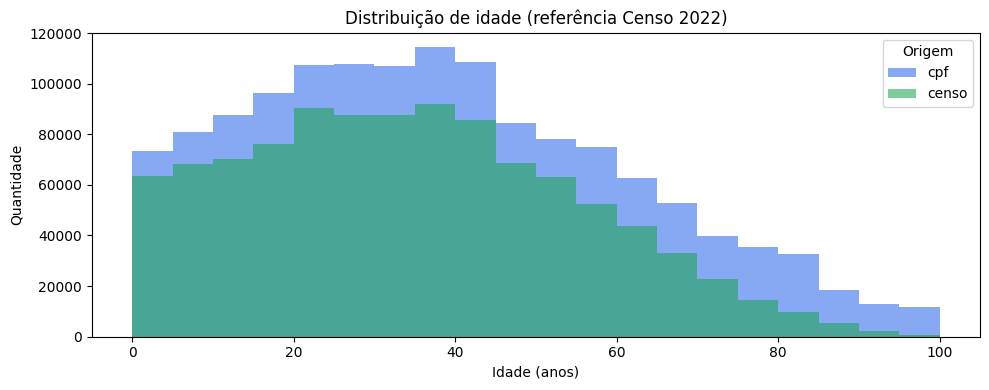

In [8]:
cols = set(con.execute(f'SELECT * FROM {TABLE} LIMIT 0').df().columns)
if 'idade' not in cols:
    print('Coluna idade ausente — rode NB00 com REBUILD=True.')
else:
    df_idade = con.execute(f"""
    SELECT origem, idade, COUNT(*) AS n
    FROM {TABLE}
    WHERE idade IS NOT NULL AND idade BETWEEN 0 AND 120
    GROUP BY origem, idade
    ORDER BY idade
    """).df()
    display(con.execute(f"""
    SELECT origem,
        COUNT(*) AS n,
        SUM(CASE WHEN idade IS NOT NULL THEN 1 ELSE 0 END) AS com_idade,
        ROUND(100.0 * SUM(CASE WHEN idade IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_idade,
        ROUND(AVG(idade), 1) AS idade_media
    FROM {TABLE}
    GROUP BY origem
    """).df())
    plot_idade_hist(df_idade)

## 6. CEP


,origem,cep5,n
0,cpf,65000,294423
1,censo,65058,115739
2,cpf,65058,115066
3,cpf,65010,59354
4,cpf,65055,40064
5,censo,65057,38939
6,censo,65082,38632
7,cpf,65040,37244
8,censo,65081,36943
9,cpf,65066,36690


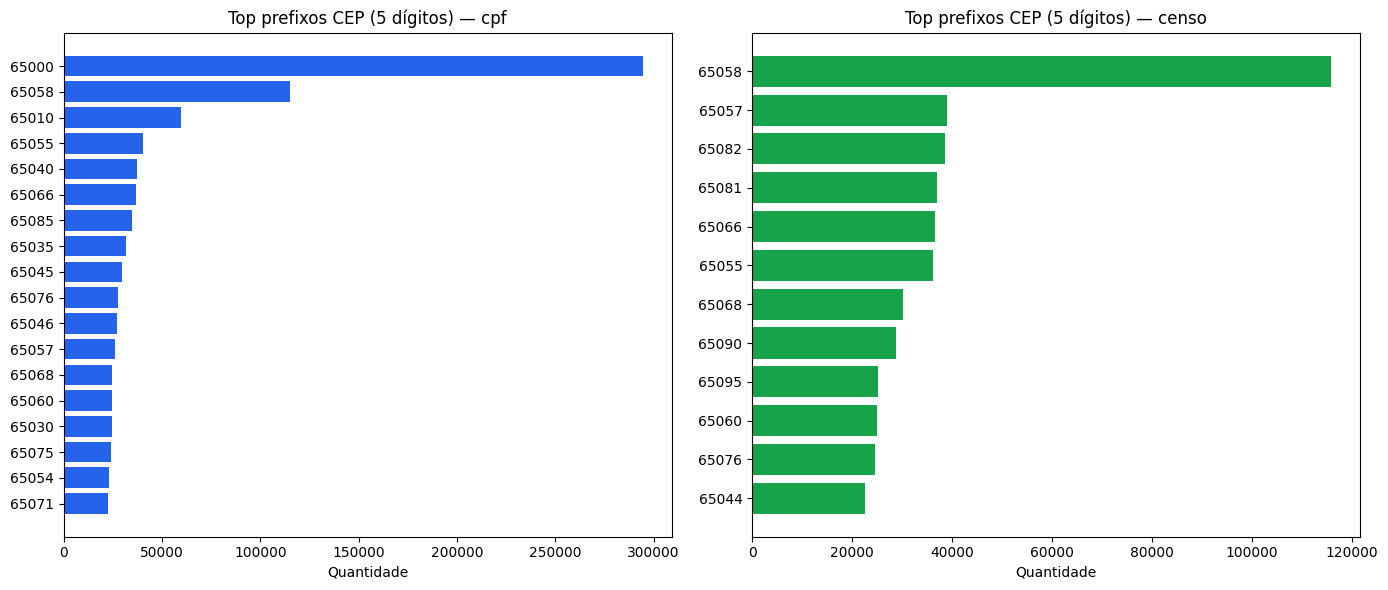

In [9]:
df_cep = con.execute(f"""
SELECT origem,
       substr(lpad(regexp_replace(CAST(cep AS VARCHAR), '[^0-9]', '', 'g'), 8, '0'), 1, 5) AS cep5,
       COUNT(*) AS n
FROM {TABLE}
WHERE {_is_filled('cep')}
GROUP BY origem, cep5
ORDER BY n DESC
LIMIT 30
""").df()
display(df_cep.head(20))
plot_cep_prefix(df_cep)

## 7. UF


,origem,uf,n
0,cpf,21,1438943
1,censo,21,1037775


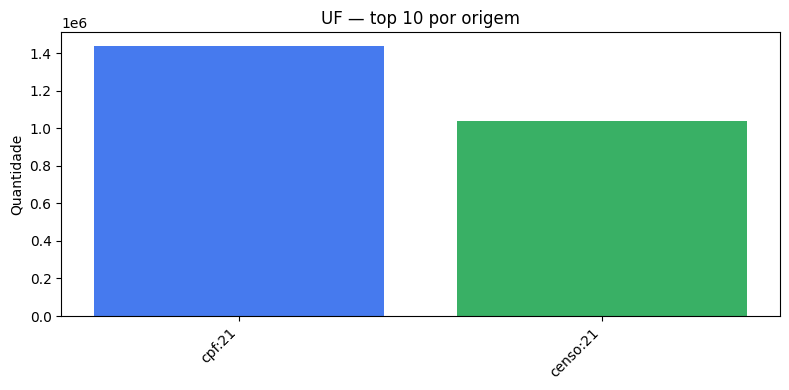

In [10]:
df_uf = con.execute(f"""
SELECT origem, CAST(uf AS VARCHAR) AS uf, COUNT(*) AS n
FROM {TABLE}
WHERE {_is_filled('uf')}
GROUP BY origem, uf
ORDER BY n DESC
""").df()
display(df_uf.head(15))
plot_uf_distribution(df_uf)

## 8. Nome da mãe


,coluna,origem,n,preenchido,pct_preenchido,pct_missing
0,nome_mae,cpf,1438943,1378016.0,95.8,4.2
1,nome_mae,censo,1037775,300294.0,28.9,71.1


--- censo ---


,origem,valor,n
0,censo,MARIA CONCEICAO,150
1,censo,MARIA SILVA,149
2,censo,MARIA SANTOS,136
3,censo,MARIA JESUS,109
4,censo,MARIA JOSE,94
5,censo,MARIA CONCEICAO SILVA,87
6,censo,MARIA SOCORRO,78
7,censo,MARIA JOSE SANTOS,76
8,censo,MARIA FATIMA,69
9,censo,MARIA CARMO,65


--- cpf ---


,origem,valor,n
15,cpf,MARIA JOSE SILVA,882
16,cpf,MARIA CONCEICAO SILVA,704
17,cpf,MARIA JOSE SANTOS,602
18,cpf,MARIA PEREIRA SILVA,494
19,cpf,MARIA CONCEICAO SANTOS,463
20,cpf,MARIA JESUS SILVA,403
21,cpf,MARIA LOURDES SILVA,372
22,cpf,MARIA JOSE COSTA,368
23,cpf,MARIA SOCORRO SILVA,334
24,cpf,MARIA JOSE PEREIRA,331


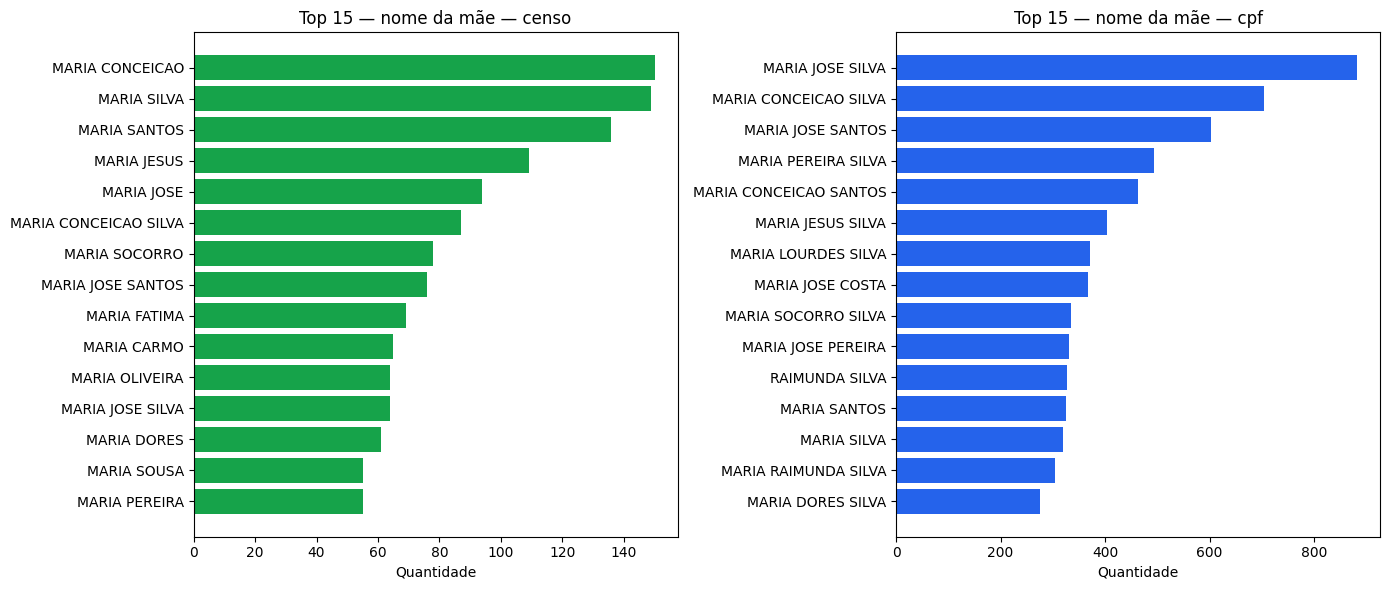

In [11]:
df_mae_miss = con.execute(f"""
SELECT
    'nome_mae' AS coluna,
    origem,
    COUNT(*) AS n,
    SUM(CASE WHEN {_is_filled('nome_mae')} THEN 1 ELSE 0 END) AS preenchido
FROM {TABLE}
GROUP BY origem
""").df()
df_mae_miss['pct_preenchido'] = (df_mae_miss['preenchido'] / df_mae_miss['n'] * 100).round(1)
df_mae_miss['pct_missing'] = (100 - df_mae_miss['pct_preenchido']).round(1)
display(df_mae_miss)

# Top 15 por origem (CPF direto vs Censo inferido)
df_mae_top = con.execute(f"""
WITH agg AS (
    SELECT origem, CAST(nome_mae AS VARCHAR) AS valor, COUNT(*) AS n
    FROM {TABLE}
    WHERE {_is_filled('nome_mae')}
    GROUP BY origem, valor
),
ranked AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY origem ORDER BY n DESC) AS rn
    FROM agg
)
SELECT origem, valor, n
FROM ranked
WHERE rn <= 15
ORDER BY origem, n DESC
""").df()
for orig in df_mae_top['origem'].unique():
    print(f'--- {orig} ---')
    display(df_mae_top[df_mae_top['origem'] == orig])
plot_top_bars(df_mae_top, title='Top 15 — nome da mãe')

## 9. Resumo

Revise acima:
- **Missingness** — colunas críticas para linkage (nome, DOB, CEP, nome_mae)
- **Nomes** — concentração nos top tokens (blocking)
- **CEP/UF** — coerência com `FILTRO_UF`


In [12]:
con.close()